In [ ]:
!nvidia-smi

Fri Feb 20 06:44:35 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P0             27W /   70W |    1343MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("briscdataset/brisc2025")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brisc2025' dataset.
Path to dataset files: /kaggle/input/brisc2025


In [ ]:
!find /kaggle/input/brisc2025 -maxdepth 3

/kaggle/input/brisc2025
/kaggle/input/brisc2025/brisc2025
/kaggle/input/brisc2025/brisc2025/manifest.json
/kaggle/input/brisc2025/brisc2025/README.md
/kaggle/input/brisc2025/brisc2025/segmentation_task
/kaggle/input/brisc2025/brisc2025/segmentation_task/test
/kaggle/input/brisc2025/brisc2025/segmentation_task/train
/kaggle/input/brisc2025/brisc2025/classification_task
/kaggle/input/brisc2025/brisc2025/classification_task/test
/kaggle/input/brisc2025/brisc2025/classification_task/train
/kaggle/input/brisc2025/brisc2025/manifest.csv
/kaggle/input/brisc2025/brisc2025/manifest.json.sha256
/kaggle/input/brisc2025/brisc2025/manifest.csv.sha256


In [ ]:
# Unzips your file quietly (-q) into Colab's local /content/ folder
!unzip -q "/content/drive/MyDrive/BRISC2025.zip" -d "/content/brisc_dataset"

unzip:  cannot find or open /content/drive/MyDrive/BRISC2025.zip, /content/drive/MyDrive/BRISC2025.zip.zip or /content/drive/MyDrive/BRISC2025.zip.ZIP.


In [ ]:
%pip install torch torchvison sklearn seaborn matplotlib numpy PIL

ERROR: Could not find a version that satisfies the requirement torchvison (from versions: none)
ERROR: No matching distribution found for torchvison


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
from sklearn.metrics import confusion_matrix



In [ ]:
TRAIN_DIR = '/kaggle/input/brisc2025/brisc2025/classification_task/train'
TEST_DIR = '/kaggle/input/brisc2025/brisc2025/classification_task/test'
input_size = 256
reshape_size =280
BATCH_SIZE=32
#TRAIN_DIR = '/content/brisc_dataset/brisc2025/classification_task/train'
#TEST_DIR = '/content/brisc_dataset/brisc2025/classification_task/test'

In [ ]:
# Define how to process the images
transform = transforms.Compose([
    transforms.Resize((reshape_size, reshape_size)),
    transforms.RandomHorizontalFlip(p=0.5), # Flips 50% of images like a mirror
    transforms.RandomRotation(degrees=15 ),
    transforms.CenterCrop((input_size, input_size)),  # Tilts the brain up to 15 degrees

    transforms.ToTensor(),
])

# Map 'no_tumor' (index 2) to 0, and all other tumors to 1
binary_transform = lambda target: 0 if target == 2 else 1

# Load dataset (make sure this path matches how your zip file is structured inside)
dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=transform,
    target_transform=binary_transform
)

train_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# 1. Load the Test Data (using the same transforms as before)
test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=transform,
    target_transform=binary_transform
)
# shuffle=False is important here so we can match predictions to the right labels
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

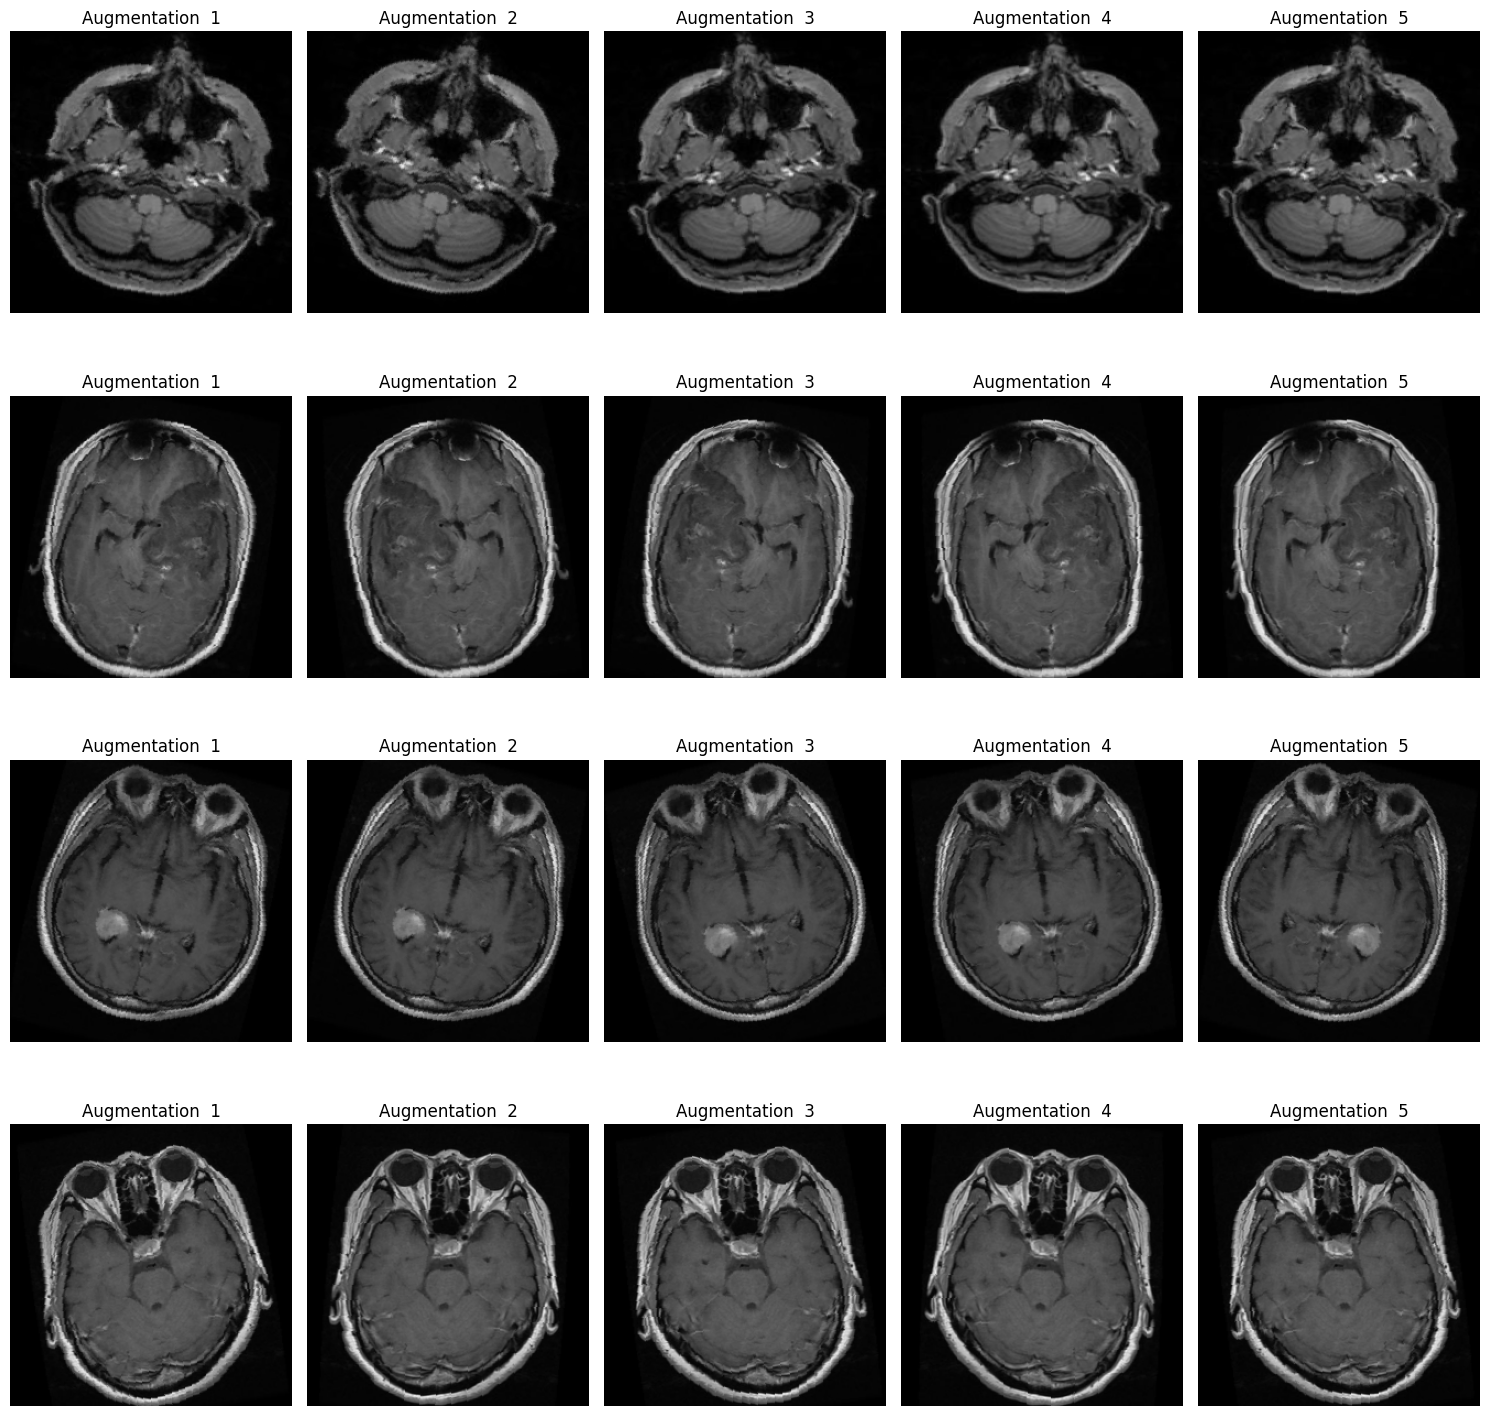

<Figure size 640x480 with 0 Axes>

In [ ]:
  # Update this path to point to an actual image in your dataset
image_paths = ["/kaggle/input/brisc2025/brisc2025/classification_task/train/no_tumor/brisc2025_train_02477_no_ax_t1.jpg",
             "/kaggle/input/brisc2025/brisc2025/classification_task/train/glioma/brisc2025_train_00001_gl_ax_t1.jpg",
             "/kaggle/input/brisc2025/brisc2025/classification_task/train/meningioma/brisc2025_train_01148_me_ax_t1.jpg",
             "/kaggle/input/brisc2025/brisc2025/classification_task/train/pituitary/brisc2025_train_03544_pi_ax_t1.jpg",
]
type_index = 0
fig, axes = plt.subplots(4, 5, figsize=(15, 15))

for image_path in image_paths:
    try:
        # Convert to RGB just in case your MRI is saved as a grayscale format
        original_image = Image.open(image_path).convert('RGB')
    except FileNotFoundError:
        print(f"Error: Could not find an image at {image_path}. Please check the path.")
        exit()

    # 4. Generate and plot 5 augmented versions
    for i in range(5):
        # Apply the transform to the original PIL image

        augmented_tensor = transform(original_image)

        # Rearrange dimensions from [C, H, W] to [H, W, C] for Matplotlib
        # We also convert it to a NumPy array for plotting
        image_to_plot = augmented_tensor.permute(1, 2, 0).numpy()

        # Display the image
        axes[type_index][i].imshow(image_to_plot)
        axes[type_index][i].axis('off') # Hides the axis grids and numbers
        axes[type_index][i].set_title(f"Augmentation  {i+1}")
    type_index += 1
# Show the final plot
plt.tight_layout()
plt.show()

# Show the final plot
plt.tight_layout()
plt.show()

In [ ]:
# Move computations to the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load a pre-trained ResNet18 model and change the last layer for binary output (1 node)
model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

# Loss Function and Optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/15 | Train Loss: 0.1007 | Val Loss: 0.2488 | Train Acc: 95.80% | Val Acc: 88.80%
Epoch 2/15 | Train Loss: 0.0639 | Val Loss: 2.2013 | Train Acc: 97.64% | Val Acc: 35.80%
Epoch 3/15 | Train Loss: 0.0590 | Val Loss: 1.5301 | Train Acc: 97.98% | Val Acc: 65.80%
Epoch 4/15 | Train Loss: 0.0763 | Val Loss: 0.2707 | Train Acc: 96.90% | Val Acc: 89.20%
Epoch 5/15 | Train Loss: 0.0384 | Val Loss: 0.0561 | Train Acc: 98.60% | Val Acc: 97.70%
Epoch 6/15 | Train Loss: 0.0547 | Val Loss: 0.2247 | Train Acc: 98.44% | Val Acc: 90.40%
Epoch 7/15 | Train Loss: 0.0590 | Val Loss: 0.0559 | Train Acc: 97.86% | Val Acc: 97.70%
Epoch 8/15 | Train Loss: 0.0310 | Val Loss: 0.0216 | Train Acc: 99.02% | Val Acc: 99.20%
Epoch 9/15 | Train Loss: 0.0450 | Val Loss: 0.7606 | Train Acc: 98.58% | Val Acc: 75.60%
Epoch 10/15 | Train Loss: 0.0246 | Val Loss: 0.0371 | Train Acc: 99.10% | Val Acc: 98.20%
Epoch 11/15 | Train Loss: 0.0140 | Val Loss: 0.0591 | Train Acc: 99.54% | Val Acc: 97.90%
Epoch 12/15 | Train

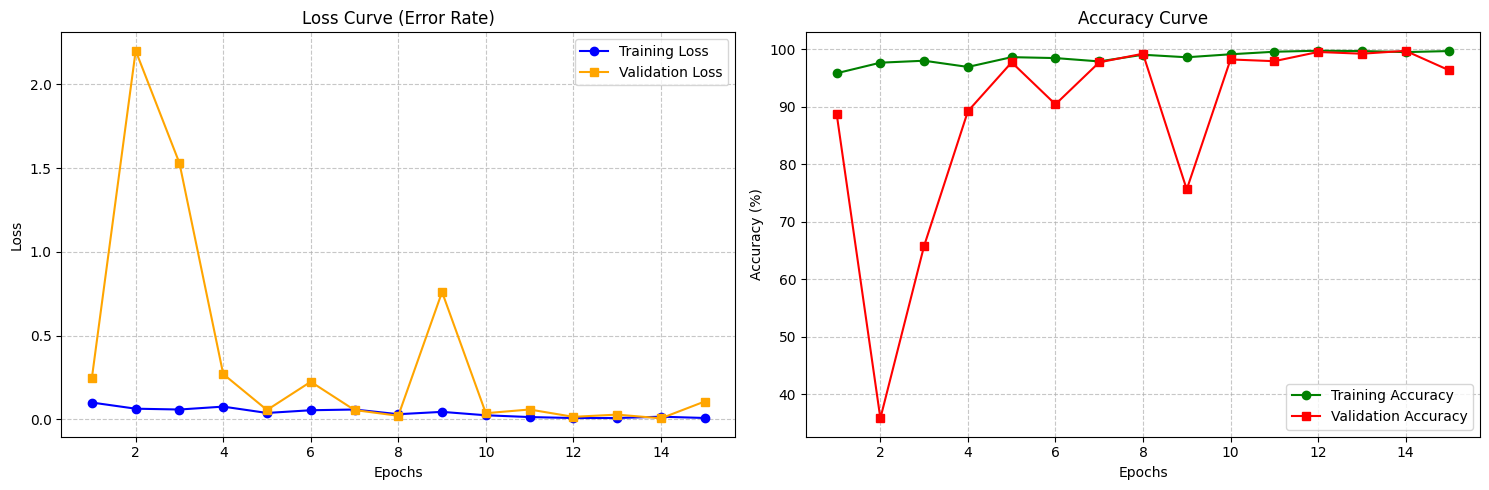

In [ ]:
import matplotlib.pyplot as plt
import torch

# Lists to store metrics for our graphs
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

epochs = 15

for epoch in range(epochs):
    # ==========================
    #      TRAINING PHASE
    # ==========================
    model.train()
    running_train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        # Accuracy math
        probs = torch.sigmoid(outputs)
        preds = (probs >= 0.5).float()
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    avg_train_loss = running_train_loss / len(train_loader)
    train_acc = (train_correct / train_total) * 100

    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    # ==========================
    #     VALIDATION PHASE
    # ==========================
    model.eval()
    running_val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in test_loader: # We use test_loader as our validation set
            images = images.to(device)
            labels = labels.to(device).float().unsqueeze(1)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            # Accuracy math
            probs = torch.sigmoid(outputs)
            preds = (probs >= 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    avg_val_loss = running_val_loss / len(test_loader)
    val_acc = (val_correct / val_total) * 100

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)



    # THE EXACT OUTPUT YOUR GUIDE WANTS
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

# ==========================
#  PLOTTING THE TWO GRAPHS
# ==========================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Graph 1: Loss
ax1.plot(range(1, epochs+1), train_losses, label='Training Loss', color='blue', marker='o')
ax1.plot(range(1, epochs+1), val_losses, label='Validation Loss', color='orange', marker='s')
ax1.set_title('Loss Curve (Error Rate)')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Graph 2: Accuracy
ax2.plot(range(1, epochs+1), train_accuracies, label='Training Accuracy', color='green', marker='o')
ax2.plot(range(1, epochs+1), val_accuracies, label='Validation Accuracy', color='red', marker='s')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:


# 2. Run the Evaluation Loop
model.eval() # Put the model in evaluation mode (turns off dropout, etc.)
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad(): # Turn off gradient tracking to save memory and compute
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).float()

        outputs = model(images).squeeze()
        probs = torch.sigmoid(outputs)    # Convert raw logits to probabilities (0.0 to 1.0)
        preds = (probs >= 0.3).float()    # Threshold at 0.5 to decide Tumor (1) or No Tumor (0)

        # Save batches to our master lists
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 3. Calculate Core Metrics
accuracy = accuracy_score(all_labels, all_preds)
sensitivity = recall_score(all_labels, all_preds) # In medicine, Recall is called Sensitivity
f1 = f1_score(all_labels, all_preds)
auc = roc_auc_score(all_labels, all_probs)

# 4. Extract Specificity from the Confusion Matrix
tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
specificity = tn / (tn + fp)

# 5. Print the Results
print(f"Accuracy:    {accuracy * 100:.2f}%")
print(f"Sensitivity: {sensitivity * 100:.2f}%")
print(f"Specificity: {specificity * 100:.2f}%")
print(f"F1-Score:    {f1:.4f}")
print(f"AUC-ROC:     {auc:.4f}")

Accuracy:    96.40%
Sensitivity: 100.00%
Specificity: 74.29%
F1-Score:    0.9795
AUC-ROC:     0.9995


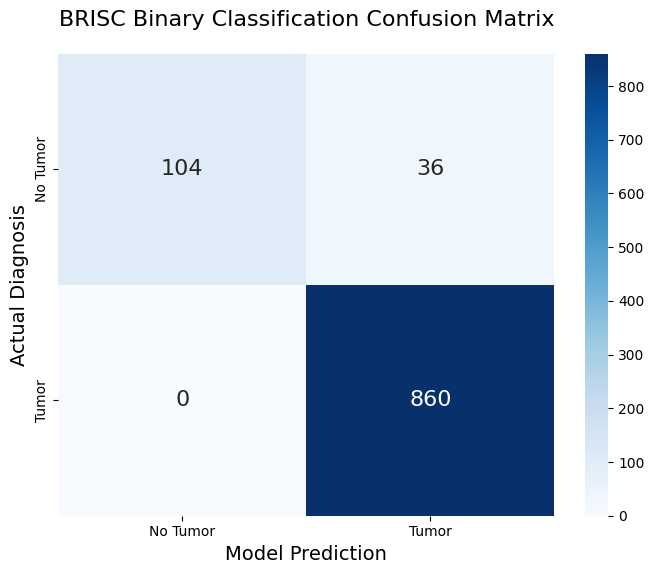

In [ ]:

# Calculate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Set up the visual plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Tumor', 'Tumor'],
            yticklabels=['No Tumor', 'Tumor'],
            annot_kws={"size": 16}) # Makes the numbers larger

# Add labels and a title
plt.ylabel('Actual Diagnosis', fontsize=14)
plt.xlabel('Model Prediction', fontsize=14)
plt.title('BRISC Binary Classification Confusion Matrix', fontsize=16, pad=20)
plt.show()

In [ ]:
torch.save(model.state_dict(), '/content/drive/MyDrive/my_brisc_binary_model.pth')